## Cat Dog Dataset

The training archive contains 25,000 images of dogs and cats. Train your algorithm on these files and predict the labels for test1.zip (1 = dog, 0 = cat).

You can obtain the dataset from https://www.kaggle.com/c/dogs-vs-cats/data

This case study is adopted from https://www.kaggle.com/uysimty/keras-cnn-dog-or-cat-classification

### 1. Import Library

In [12]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
#from keras.preprocessing.image import ImageDataGenerator, load_img
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os


#mypath='/Users/gceran/Google Drive/Courses/MagniMind/Mentorship Program/DL-MentorProgram/DL_Mentor_Week2/Class 1/input'
#print(os.listdir(mypath))
#print(os.listdir("../input"))

In [13]:
#mypath= '/Users/gceran/Google Drive/Courses/MagniMind/Mentorship Program/DL-MentorProgram/DL_Mentor_Week2/Class 1/input'
#print(os.listdir(mypath))
#print(os.listdir("../input"))

### 2. Define Constants

In [14]:
FAST_RUN = True #False
IMAGE_WIDTH=128
IMAGE_HEIGHT=128
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT)
IMAGE_CHANNELS=3

### 3. Prepare Training Data

In [21]:
import os
import pandas as pd

train_dir = '/Users/matthewcavanaugh/Desktop/GitHub Local/dogs-vs-cats/train'

# list only image files (adjust extensions if needed)
filenames = [f for f in os.listdir(train_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# label from filename prefix
categories = ['cat' if f.startswith('cat') else 'dog' for f in filenames]

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

print(df.shape)        # should be (25000, 2) if your folder has 25k images
df.head()

(25000, 2)


,filename,category
0,dog.8011.jpg,dog
1,cat.5077.jpg,cat
2,dog.7322.jpg,dog
3,cat.2718.jpg,cat
4,cat.10151.jpg,cat


#### See Total In count

In [22]:
df['category'].value_counts()

category
dog    12500
cat    12500
Name: count, dtype: int64

From our data we have 12000 cats and 12000 dogs

#### See sample image

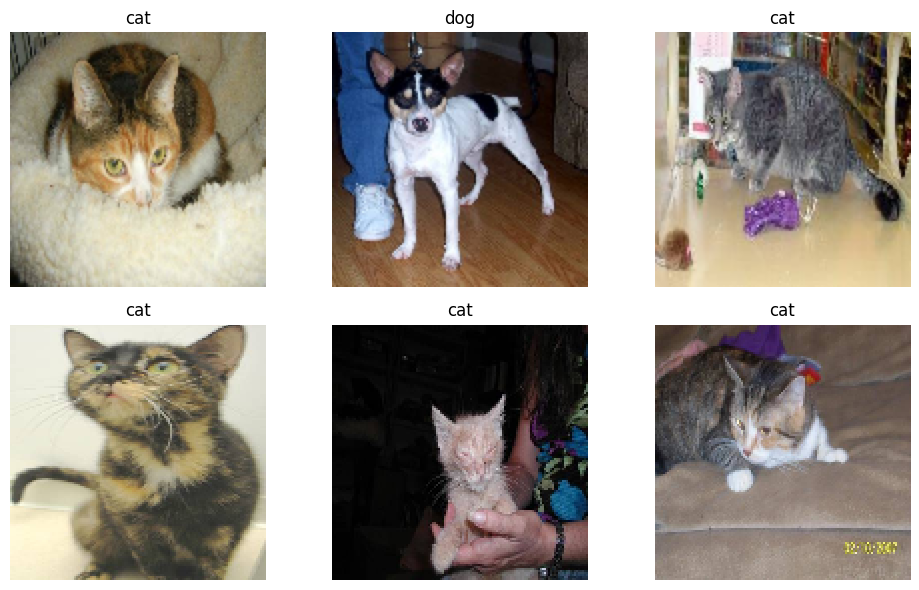

In [23]:
plt.figure(figsize=(10, 6))

for i in range(6):
    sample = random.choice(df.index)
    filename = df.loc[sample, 'filename']
    category = df.loc[sample, 'category']
    
    img_path = os.path.join(train_dir, filename)
    image = load_img(img_path, target_size=IMAGE_SIZE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 4. Build Model

<img src="https://i.imgur.com/ebkMGGu.jpg" width="100%"/>

* **Input Layer**: It represent input image data. It will reshape image into single dimension array. Example your image is 64x64 = 4096, it will convert to (4096,1) array.
* **Conv Layer**: This layer will extract features from image.
* **Pooling Layer**: This layer reduces the spatial volume of input image after convolution.
* **Fully Connected Layer**: It connect the network from a layer to another layer
* **Output Layer**: It is the predicted values layer. 

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)


model = Sequential()

# =========================
# Input + Convolution Block 1
# =========================
model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# =========================
# Convolution Block 2
# =========================
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# =========================
# Convolution Block 3
# =========================
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# =========================
# Fully Connected Layers
# =========================
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# =========================
# Output Layer
# =========================
model.add(Dense(1, activation='sigmoid'))


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,225 (49.36 MB)

 Trainable params: 12,939,777 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

### 5. Callbacks

**Early Stop**

Keras supports the early stopping of training via a callback called EarlyStopping.

This callback allows you to specify the performance measure to monitor, the trigger, and once triggered, it will stop the training process.

The `EarlyStopping` callback is configured when instantiated via arguments.

The `monitor` allows you to specify the performance measure to monitor in order to end training.

To prevent over fitting we will stop the learning after 10 epochs and val_loss value not decreased

In [27]:
from tensorflow.keras.callbacks import EarlyStopping


earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

**Learning Rate Reduction**

We will reduce the learning rate when then accuracy not increase for 2 steps

In [28]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)

In [29]:
callbacks = [earlystop, learning_rate_reduction]

### 6. Prepare data

Because we will use image genaretor `with class_mode="categorical"`. We need to convert column category into string. Then imagenerator will convert it one-hot encoding which is good for our classification. 

So we will convert 1 to dog and 0 to cat

NOTE - Already set string labels

In [30]:
train_df = df.copy()
train_df

,filename,category
0,dog.8011.jpg,dog
1,cat.5077.jpg,cat
2,dog.7322.jpg,dog
3,cat.2718.jpg,cat
4,cat.10151.jpg,cat
...,...,...
24995,dog.8008.jpg,dog
24996,dog.1992.jpg,dog
24997,dog.12412.jpg,dog
24998,cat.2701.jpg,cat


# 6b - Creating dataframes

In [31]:
from sklearn.model_selection import train_test_split

train_df, validate_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['category']
)

train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

print("Train samples:", len(train_df))
print("Validation samples:", len(validate_df))


Train samples: 20000
Validation samples: 5000


### 7. Traning Generator

In [33]:
# Version 2
train_dir = '/Users/matthewcavanaugh/Desktop/GitHub Local/dogs-vs-cats/train'

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=train_dir,
    x_col='filename',
    y_col='category',
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode='binary',
    classes=['cat', 'dog'],
    shuffle=True
)

Found 20000 validated image filenames belonging to 2 classes.


### Validation Generator

In [35]:
# Version 2
validation_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = validation_datagen.flow_from_dataframe(
    validate_df,
    directory=train_dir,
    x_col='filename',
    y_col='category',
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode='binary',
    classes=['cat', 'dog'],
    shuffle=False
)


Found 5000 validated image filenames belonging to 2 classes.


In [36]:
train_generator.class_indices


{'cat': 0, 'dog': 1}

### 8. See how our generator work

Seem to be nice 

### 9. Fit Model

In [37]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/20


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 306ms/step - accuracy: 0.5974 - loss: 2.0705 - val_accuracy: 0.6382 - val_loss: 0.7191 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 237s 379ms/step - accuracy: 0.6711 - loss: 0.5984 - val_accuracy: 0.7424 - val_loss: 0.5287 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 301s 481ms/step - accuracy: 0.7170 - loss: 0.5631 - val_accuracy: 0.7452 - val_loss: 0.5436 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 240s 383ms/step - accuracy: 0.7416 - loss: 0.5298 - val_accuracy: 0.7814 - val_loss: 0.4649 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 245s 392ms/step - accuracy: 0.7711 - loss: 0.4901 - val_accuracy: 0.6802 - val_loss: 0.9719 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.7912 - loss: 0.4526
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
625/625 ━━━━━━━━━━━━━━━━━━━━ 262s 419ms/step - accuracy: 0.7912 - l

### 10. Save Model

In [40]:
model.save("model.cat_dog.keras")

### 10a. Load Model

In [41]:
model.save("model.cat_dog.keras")

from keras.models import load_model
model = load_model('model.cat_dog.keras')

# This should work when reloading - going to try it on a copy, not here
# rebuild validation_generator exactly like you did
val_loss, val_acc = model.evaluate(validation_generator)
print(val_loss, val_acc)

### 11. Virtualize Training (did this mean to say Visualize?)

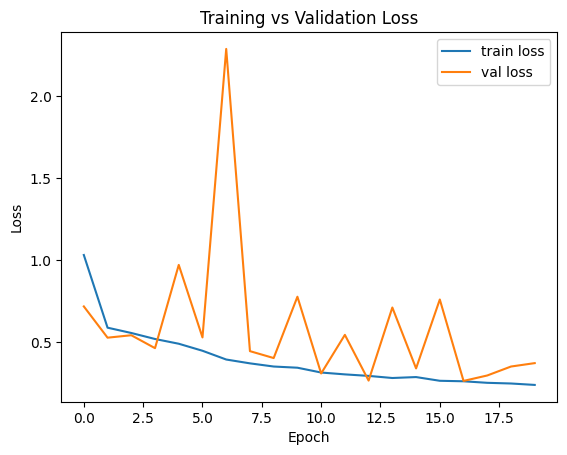

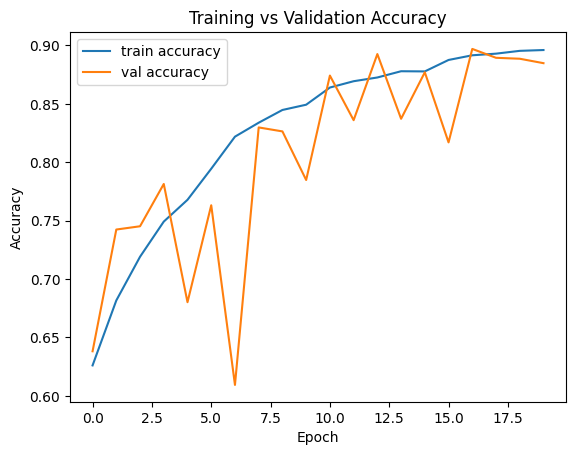

In [42]:
import matplotlib.pyplot as plt

def plot_history(history):
    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training vs Validation Loss')
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training vs Validation Accuracy')
    plt.show()

plot_history(history)


### 12. Prepare Testing Data

In [43]:
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = '/Users/matthewcavanaugh/Desktop/GitHub Local/dogs-vs-cats/test'

# List test images
test_filenames = [
    f for f in os.listdir(test_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

test_df = pd.DataFrame({
    'filename': test_filenames
})

test_df.head()


,filename
0,9733.jpg
1,63.jpg
2,6400.jpg
3,823.jpg
4,4217.jpg


### 13. Create Testing Generator

In [44]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=test_dir,
    x_col='filename',
    y_col=None,                 # no labels
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode=None,            # IMPORTANT
    shuffle=False               # preserve order
)


Found 12500 validated image filenames.


### 14. Predict

In [45]:
import numpy as np
import pandas as pd

# Predict probabilities (typically: probability of class "dog" if you trained with classes=['cat','dog'])
pred_probs = model.predict(test_generator, verbose=1).ravel()

# Convert to 0/1 with threshold
pred_labels = (pred_probs >= 0.5).astype(int)

# Attach to dataframe (order matches test_generator because shuffle=False)
test_df = test_df.copy()
test_df["prob_dog"] = pred_probs
test_df["pred"] = pred_labels
test_df["pred_class"] = test_df["pred"].map({0: "cat", 1: "dog"})

test_df.head()


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step


,filename,prob_dog,pred,pred_class
0,9733.jpg,1.298065e-04,0,cat
1,63.jpg,1.081267e-02,0,cat
2,6400.jpg,9.740701e-01,1,dog
3,823.jpg,9.999999e-01,1,dog
4,4217.jpg,4.163400e-08,0,cat


#### Virtualize Result

### 15. See predicted result with images

Confidence is in class=dog.

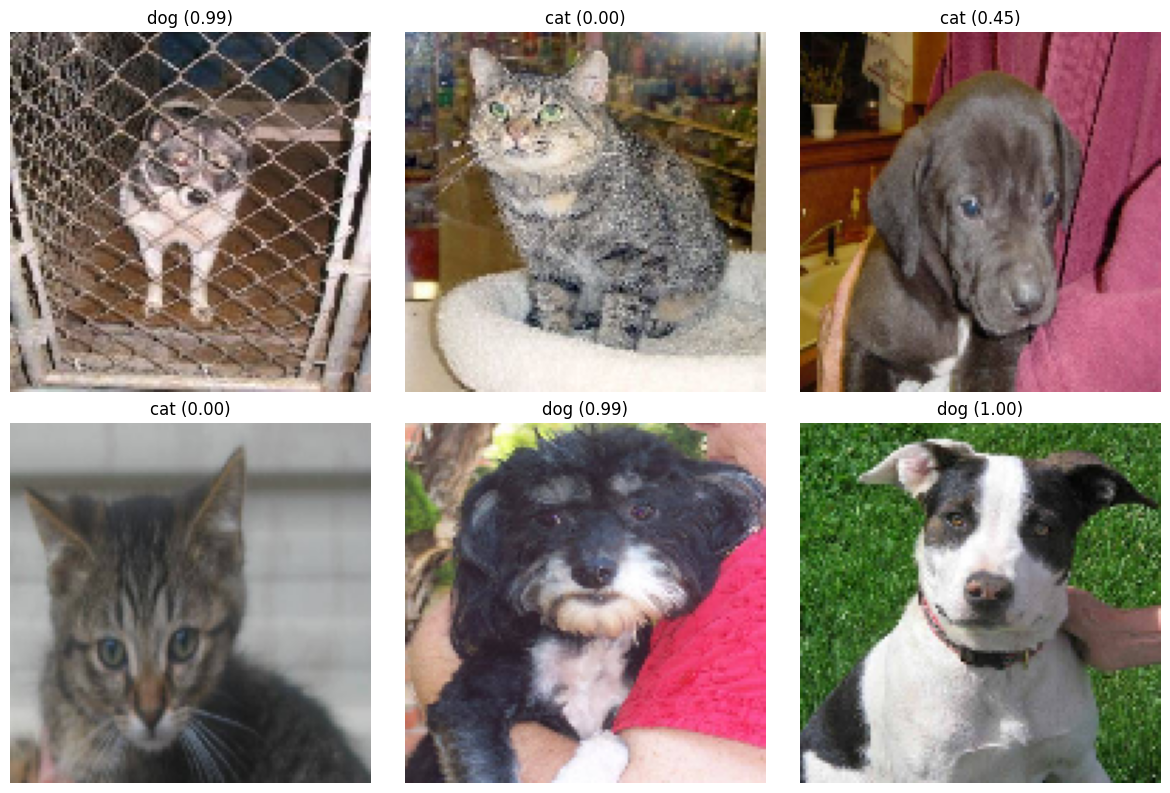

In [46]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import os

sample = test_df.sample(6, random_state=42)

plt.figure(figsize=(12, 8))
for i, row in enumerate(sample.itertuples(index=False), 1):
    img = load_img(os.path.join(test_dir, row.filename), target_size=IMAGE_SIZE)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(f"{row.pred_class} ({row.prob_dog:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.show()


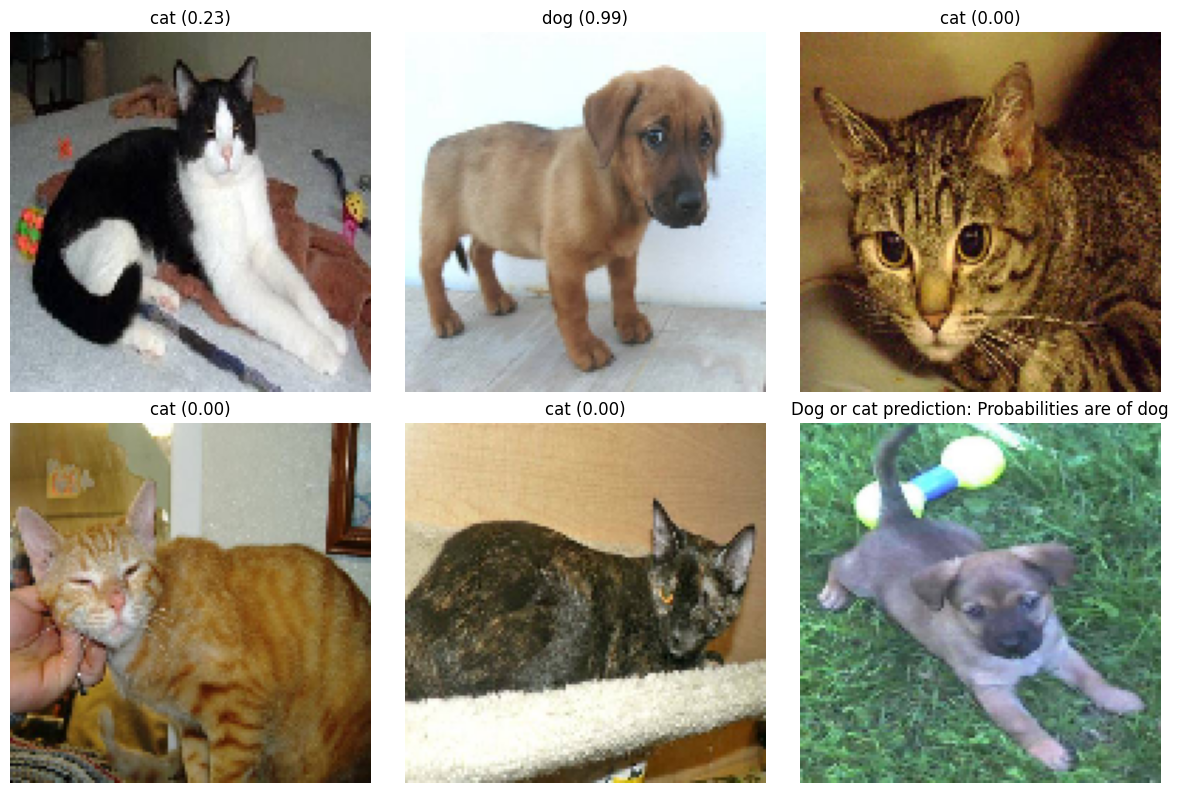

In [49]:
sample = test_df.sample(6, random_state=3)

plt.figure(figsize=(12, 8))
for i, row in enumerate(sample.itertuples(index=False), 1):
    img = load_img(os.path.join(test_dir, row.filename), target_size=IMAGE_SIZE)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(f"{row.pred_class} ({row.prob_dog:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.show()